# PQC IoT Result Analysis

This notebook reads handshake and byte-size benchmark results and shows simple plots.

In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

results_dir = Path("../results")
handshake_path = results_dir / "handshake_results.csv"
bytes_path = results_dir / "bytes_results.csv"

if handshake_path.exists():
    handshake_df = pd.read_csv(
        handshake_path,
        header=None,
        names=["mode", "iteration", "handshake_ms"]
    )
else:
    handshake_df = pd.DataFrame()

if bytes_path.exists():
    bytes_df = pd.read_csv(bytes_path)
else:
    bytes_df = pd.DataFrame()

display(handshake_df.head())
display(bytes_df.head())

,mode,iteration,handshake_ms
0,ML-KEM-512,1,0.075792
1,ML-KEM-512,2,0.055958
2,ML-KEM-512,3,0.055167
3,ML-KEM-512,4,0.058250
4,ML-KEM-512,5,0.053667


,mode,public_key_bytes,ciphertext_bytes,payload_bytes
0,ML-KEM-512,800,768,1069
1,X25519,32,0,60


In [14]:
required_cols = {"mode", "handshake_ms"}

if handshake_df.empty:
    print("No handshake results found yet.")
elif not required_cols.issubset(handshake_df.columns):
    print("Handshake CSV is missing expected columns.")
    print("Found columns:", handshake_df.columns.tolist())
    display(handshake_df.head())
else:
    summary = handshake_df.groupby("mode")["handshake_ms"].agg(["mean", "median", "max"])
    display(summary)

,mean,median,max
mode,,,
ML-KEM-512,0.052999,0.051584,0.139250
X25519,0.333263,0.329647,0.421625


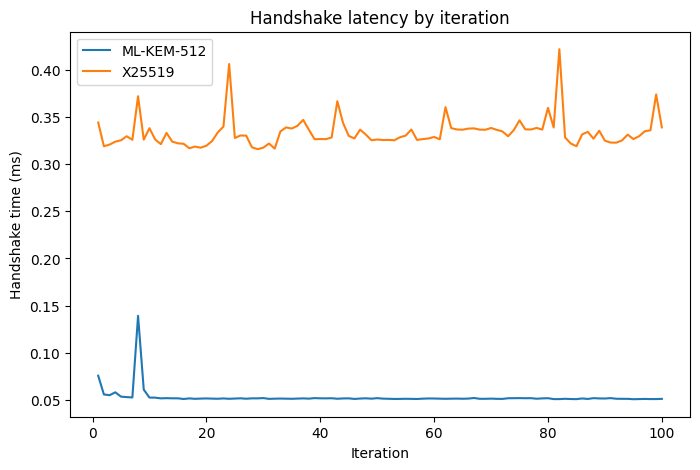

In [15]:
required_cols = {"mode", "iteration", "handshake_ms"}

if handshake_df.empty:
    print("No handshake results to plot.")
elif not required_cols.issubset(handshake_df.columns):
    print("Handshake CSV is missing expected columns.")
    print("Found columns:", handshake_df.columns.tolist())
    display(handshake_df.head())
else:
    plt.figure(figsize=(8, 5))
    for mode, group in handshake_df.groupby("mode"):
        plt.plot(group["iteration"], group["handshake_ms"], label=mode)
    plt.xlabel("Iteration")
    plt.ylabel("Handshake time (ms)")
    plt.title("Handshake latency by iteration")
    plt.legend()
    plt.show()

,mode,public_key_bytes,ciphertext_bytes,payload_bytes
0,ML-KEM-512,800,768,1069
1,X25519,32,0,60


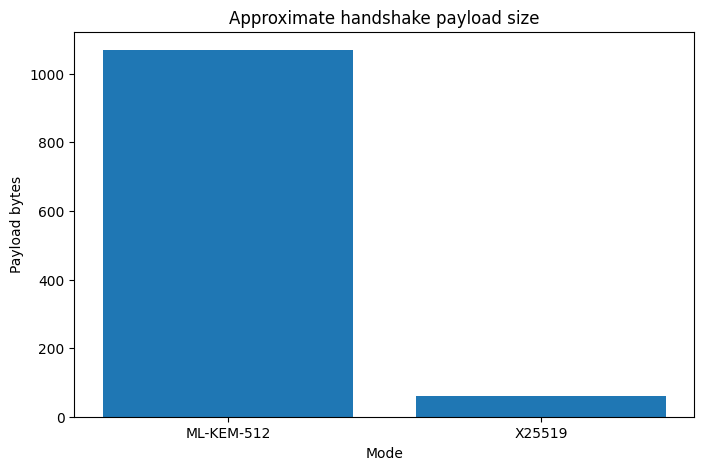

In [16]:
if not bytes_df.empty:
    display(bytes_df)

    plt.figure(figsize=(8, 5))
    plt.bar(bytes_df["mode"], bytes_df["payload_bytes"])
    plt.xlabel("Mode")
    plt.ylabel("Payload bytes")
    plt.title("Approximate handshake payload size")
    plt.show()
else:
    print("No byte-size results found yet.")

In [11]:
import pandas as pd
from pathlib import Path

handshake_path = Path("../results/handshake_results.csv")
raw = pd.read_csv(handshake_path)
print(raw.columns.tolist())
display(raw.head(10))

['ML-KEM-512', '1', '0.075792']


,ML-KEM-512,1,0.075792
0,ML-KEM-512,2,0.055958
1,ML-KEM-512,3,0.055167
2,ML-KEM-512,4,0.058250
3,ML-KEM-512,5,0.053667
4,ML-KEM-512,6,0.053167
5,ML-KEM-512,7,0.052791
6,ML-KEM-512,8,0.139250
7,ML-KEM-512,9,0.061084
8,ML-KEM-512,10,0.052666
9,ML-KEM-512,11,0.052583


In [12]:
print(handshake_df.columns.tolist())
display(handshake_df.head())

['ML-KEM-512', '1', '0.075792']


,ML-KEM-512,1,0.075792
0,ML-KEM-512,2,0.055958
1,ML-KEM-512,3,0.055167
2,ML-KEM-512,4,0.058250
3,ML-KEM-512,5,0.053667
4,ML-KEM-512,6,0.053167
